# Figure 3

Effects of capacity, group size, and capacity sequencing on efficiency.

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy import stats
from collections import defaultdict

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import *

In [2]:
path_to_data = PATHS['human_data'] / 'processed_human_data.csv'
data = pd.read_csv(path_to_data)

gm = GetMeasurements(
    data=data, 
    measures=[
        'efficiency', 'bounded_efficiency', 'gini_index', 
        'entropy', 'min_entropy',
    ],
    T=20
)
gm.columns.append('threshold_bin')
df_measures = gm.get_measurements()

In [3]:
path_to_data = PATHS['human_data'] / 'multi-player.csv'
data = pd.read_csv(path_to_data)
data['model'] = data.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)

gm = GetMeasurements(
    data=data, 
    measures=[
        'bounded_efficiency', 'entropy',
        'inequality', 'conditional_entropy', 'conditional_entropy_2nd_order', 'min_entropy'
    ],
    T=20
)
gm.columns.append('session')
gm.columns.append('approx_threshold')
print(gm.columns)
df = gm.get_measurements()
df['model'] = df.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)

ai = AlternationIndex.from_file(priority='mlp')
df['predicted_class'] = ai.classify(df)

df_best = df[df['bounded_efficiency'] > 0.87]
df_best = df_best[df_best['threshold'] < 1]

['model', 'treatment', 'threshold', 'num_players', 'group', 'session', 'approx_threshold']


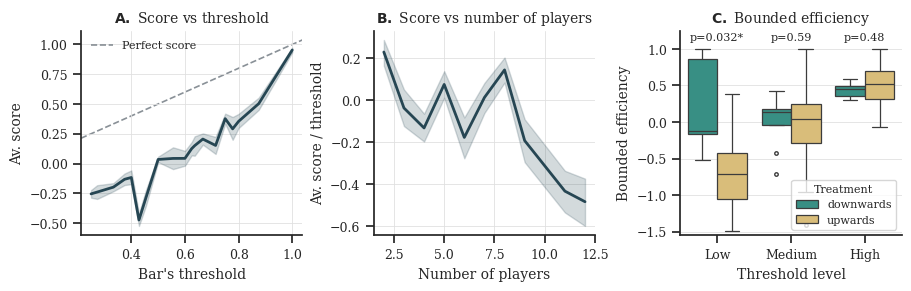

In [4]:
# Figure: panels D, E, F in a single row
sns.set_theme(style='ticks', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

LINE_COLOR = '#264653'
REF_COLOR = '#6C757D'
TREATMENT_PALETTE = {'downwards': '#2A9D8F', 'upwards': '#E9C46A'}

plot_df = df_measures[df_measures['num_players'] >= 3].copy()
bin_order = ['Low', 'Medium', 'High']


def annotate_binwise_welch(ax, data, x, y, hue, order=None):
    hues = sorted(data[hue].dropna().unique())
    if len(hues) != 2:
        raise ValueError(f'Welch t-test needs exactly 2 {hue} levels; got {hues}')
    h0, h1 = hues[0], hues[1]

    labels = [t.get_text() for t in ax.get_xticklabels()]
    y_lo, y_hi = ax.get_ylim()
    pad = 0.03 * (y_hi - y_lo)
    tops = []

    for i, xv in enumerate(labels):
        sub = data[data[x].astype(str) == str(xv)]
        a = sub.loc[sub[hue] == h0, y].dropna().to_numpy()
        b = sub.loc[sub[hue] == h1, y].dropna().to_numpy()
        if len(a) < 2 or len(b) < 2:
            continue
        _, p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
        if p < 1e-4:
            ps = 'p<1e-4'
        elif p < 0.001:
            ps = 'p<0.001'
        elif p < 0.05:
            ps = f'p={p:.3f}*'
        else:
            ps = f'p={p:.2f}'
        ymax = float(sub[y].max())
        tops.append(ymax + pad)
        ax.text(i, ymax + pad, ps, ha='center', va='bottom', fontsize=8)

    if tops:
        ax.set_ylim(y_lo, max(y_hi, max(tops) + pad))


# Score normalized by session threshold
data_plot = data[data['threshold'] > 0].copy()
data_plot['score_norm'] = data_plot['score'] / data_plot['threshold']

fig_def, ax = plt.subplots(1, 3, figsize=(9, 2.8), constrained_layout=True)

# D. Score vs threshold
sns.lineplot(
    x='threshold', y='score',
    data=data, ax=ax[0],
    color=LINE_COLOR, linewidth=2,
    errorbar=('ci', 95),
)
x_lo, x_hi = ax[0].get_xlim()
ax[0].plot(
    [x_lo, x_hi], [x_lo, x_hi],
    color=REF_COLOR, linestyle='--', linewidth=1.2, alpha=0.8, zorder=0,
    label='Perfect score',
)
ax[0].set_xlim(x_lo, x_hi)
ax[0].set_xlabel("Bar's threshold")
ax[0].set_ylabel('Av. score')
ax[0].set_title(r'$\bf{A.}$ Score vs threshold')
ax[0].grid(True, color='0.88', linewidth=0.6)
ax[0].set_axisbelow(True)
ax[0].legend(frameon=False, fontsize=8, loc='best')

# E. Score vs number of players (score / threshold)
sns.lineplot(
    x='num_players', y='score_norm',
    data=data_plot, ax=ax[1],
    color=LINE_COLOR, linewidth=2,
    errorbar=('ci', 95),
)
ax[1].set_xlabel('Number of players')
ax[1].set_ylabel('Av. score / threshold')
ax[1].set_title(r'$\bf{B.}$ Score vs number of players')
# E uses score/threshold; do not share y-limits with D
ax[1].grid(True, color='0.88', linewidth=0.6)
ax[1].set_axisbelow(True)

# F. Bounded efficiency by threshold level and treatment
sns.boxplot(
    data=plot_df,
    x='threshold_bin',
    y='bounded_efficiency',
    hue='treatment',
    order=bin_order,
    palette=TREATMENT_PALETTE,
    ax=ax[2],
    linewidth=0.9,
    fliersize=2.5,
)
annotate_binwise_welch(
    ax[2], plot_df, 'threshold_bin', 'bounded_efficiency', 'treatment'
)
ax[2].set_ylim(-1.55, 1.25)
ax[2].set_xlabel('Threshold level')
ax[2].set_ylabel('Bounded efficiency')
ax[2].set_title(r'$\bf{C.}$ Bounded efficiency')
ax[2].grid(True, color='0.88', linewidth=0.6, axis='y')
ax[2].set_axisbelow(True)
ax[2].legend(title='Treatment', frameon=True, fontsize=8, title_fontsize=8, loc='lower right')

for a in ax.ravel():
    sns.despine(ax=a)

plt.show()
fig_def.savefig(PATHS['exploratory_figures'] / 'Fig3_DEF.png', dpi=300, bbox_inches='tight')
